# 03 — Frequency and TF-IDF Analysis

This clean notebook performs the core lexical comparison:

1. Filter the word-level table to content words.
2. Count lemma frequencies by genre.
3. Use TF-IDF to identify distinctive lexemes for each genre.
4. Export tables and figures for the paper/poster.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis")
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
DOCS_DIR = PROJECT_DIR / "docs"
POSTER_DIR = PROJECT_DIR / "poster"

for folder in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, DOCS_DIR, POSTER_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.chdir(NOTEBOOK_DIR)
print("Project directory:", PROJECT_DIR)
print("Current folder:", os.getcwd())


!pip -q install pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

Mounted at /content/drive
Project directory: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis
Current folder: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/notebooks


## 2. Load the processed token table

In [2]:
tokens_path = PROCESSED_DIR / "biblical_hebrew_tokens.csv"
tokens = pd.read_csv(tokens_path)

print("Total tokens:", len(tokens))
print("Columns:", list(tokens.columns))
print("\nTokens by genre:")
print(tokens.groupby("genre").size().sort_values(ascending=False))

tokens.head()

Total tokens: 28215
Columns: ['book', 'chapter', 'verse', 'genre', 'word_node', 'word', 'lex', 'pos', 'word_utf8', 'gloss']

Tokens by genre:
genre
Narrative        8527
Prophecy         7205
Poetry_Wisdom    6324
Law              6159
dtype: int64


,book,chapter,verse,genre,word_node,word,lex,pos,word_utf8,gloss
0,Genesis,37,1,Narrative,20165,וַ,W,conj,וַ,and
1,Genesis,37,1,Narrative,20166,יֵּ֣שֶׁב,JCB[,verb,יֵּ֣שֶׁב,sit
2,Genesis,37,1,Narrative,20167,יַעֲקֹ֔ב,J<QB/,nmpr,יַעֲקֹ֔ב,Jacob
3,Genesis,37,1,Narrative,20168,בְּ,B,prep,בְּ,in
4,Genesis,37,1,Narrative,20169,אֶ֖רֶץ,>RY/,subs,אֶ֖רֶץ,earth


## 3. Filter to content words

The analysis focuses on nouns, verbs, adjectives, and adverbs. It excludes function-word categories such as particles, prepositions, conjunctions, articles, pronouns, and proper names.

This makes the genre comparison more interpretable because it emphasizes lexical content rather than grammatical structure.

In [3]:
CONTENT_POS = {"subs", "verb", "adjv", "advb"}

content = tokens[tokens["pos"].isin(CONTENT_POS)].copy()
content = content.dropna(subset=["lex"])

content["lex"] = content["lex"].astype(str).str.strip()
content["lex_clean"] = content["lex"]

content.to_csv(PROCESSED_DIR / "biblical_hebrew_content_tokens.csv", index=False)

print("Content tokens:", len(content))
print("\nContent tokens by genre:")
print(content.groupby("genre").size().sort_values(ascending=False))

content.head()

Content tokens: 14707

Content tokens by genre:
genre
Narrative        4057
Poetry_Wisdom    3978
Prophecy         3701
Law              2971
dtype: int64


,book,chapter,verse,genre,word_node,word,lex,pos,word_utf8,gloss,lex_clean
1,Genesis,37,1,Narrative,20166,יֵּ֣שֶׁב,JCB[,verb,יֵּ֣שֶׁב,sit,JCB[
4,Genesis,37,1,Narrative,20169,אֶ֖רֶץ,>RY/,subs,אֶ֖רֶץ,earth,>RY/
5,Genesis,37,1,Narrative,20170,מְגוּרֵ֣י,MGWRJM/,subs,מְגוּרֵ֣י,neighbourhood,MGWRJM/
6,Genesis,37,1,Narrative,20171,אָבִ֑יו,>B/,subs,אָבִ֑יו,father,>B/
8,Genesis,37,1,Narrative,20173,אֶ֖רֶץ,>RY/,subs,אֶ֖רֶץ,earth,>RY/


## 4. Lemma frequencies by genre

In [4]:
genre_word_frequencies = (
    content
    .groupby(["genre", "lex_clean"])
    .size()
    .reset_index(name="frequency")
    .sort_values(["genre", "frequency"], ascending=[True, False])
)

genre_word_frequencies.to_csv(TABLES_DIR / "genre_word_frequencies.csv", index=False)

top_frequencies = genre_word_frequencies.groupby("genre").head(20)
top_frequencies.head(20)

,genre,lex_clean,frequency
272,Law,KL/,126
71,Law,>LHJM/,82
69,Law,>KL[,72
270,Law,KHN/,62
351,Law,MZBX/,56
9,Law,<FH[,49
431,Law,QRB[,49
115,Law,BN/,48
375,Law,NTN[,39
396,Law,PNH/,39


## 5. TF-IDF by genre

In [5]:
# Small manual gloss map for clearer figures and tables.
# The computational analysis still uses BHSA lexeme codes; glosses are only for readability.
MANUAL_GLOSSES = {
    "MNXH/": "offering",
    "KOHN/": "priest",
    "QRBN/": "offering",
    "QDC=/": "holy",
    "MXY/": "command",
    ">C/": "fire",
    "MW<D/": "appointed time",
    "FR<H/": "Pharaoh",
    "XLM/": "dream",
    "YRD/": "go down",
    ">DWN/": "lord/master",
    "MLK/": "king",
    "CR/": "official",
    "RC</": "wicked",
    "LB/": "heart",
    "YCR/": "righteous",
    "XKM/": "wise",
    "MZMWR/": "psalm",
    "DRK/": "way",
    "MWSR/": "instruction",
    "NPC/": "soul/life",
    "N>M/": "oracle",
    "YHWH/": "YHWH",
    "CB>/": "army/host",
    "KH/": "thus",
    ">RMWN/": "palace",
    "GLH/": "exile",
    "XRB/": "sword",
    "RWX/": "spirit",
}

def clean_lexeme(lex):
    return str(lex).strip()

def display_label(lex):
    lex = clean_lexeme(lex)
    return MANUAL_GLOSSES.get(lex, lex)


genre_documents = (
    content
    .groupby("genre")["lex_clean"]
    .apply(lambda values: " ".join(values.astype(str)))
    .sort_index()
)

vectorizer = TfidfVectorizer(
    lowercase=False,
    tokenizer=str.split,
    token_pattern=None,
    min_df=1,
)

tfidf_matrix = vectorizer.fit_transform(genre_documents.values)
terms = vectorizer.get_feature_names_out()
genres = genre_documents.index.tolist()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=genres, columns=terms)

tfidf_long = (
    tfidf_df
    .reset_index(names="genre")
    .melt(id_vars="genre", var_name="lex_clean", value_name="tfidf")
    .sort_values(["genre", "tfidf"], ascending=[True, False])
)

tfidf_long["display"] = tfidf_long["lex_clean"].map(display_label)

tfidf_long.to_csv(TABLES_DIR / "tfidf_by_genre.csv", index=False)

top_15_tfidf = tfidf_long.groupby("genre").head(15).reset_index(drop=True)
top_15_tfidf.to_csv(TABLES_DIR / "top_15_tfidf_by_genre.csv", index=False)

top_15_tfidf.head(30)

,genre,lex_clean,tfidf,display
0,Law,KL/,0.411578,KL/
1,Law,MZBX/,0.276366,MZBX/
2,Law,>LHJM/,0.267852,>LHJM/
3,Law,KHN/,0.247714,KHN/
4,Law,>KL[,0.235188,>KL[
5,Law,QRBN/,0.200306,offering
6,Law,<FH[,0.160058,<FH[
7,Law,QRB[,0.160058,QRB[
8,Law,BN/,0.156792,BN/
9,Law,>CH=/,0.143970,>CH=/


## 6. Summary table with interpretation

In [6]:
INTERPRETATIONS = {
    "Law": "Ritual, priestly, sacrificial, cultic, and legal vocabulary.",
    "Narrative": "Characters, movement, dreams, speech situations, and political authority.",
    "Poetry_Wisdom": "Moral, psychological, reflective, and didactic vocabulary.",
    "Prophecy": "Divine speech, political language, military imagery, and judgment.",
}

summary_rows = []
for genre, group in top_15_tfidf.groupby("genre"):
    summary_rows.append({
        "genre": genre,
        "top_lemmas": ", ".join(group["lex_clean"].head(12)),
        "readable_labels": ", ".join(group["display"].head(12)),
        "interpretation": INTERPRETATIONS.get(genre, ""),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(TABLES_DIR / "top_tfidf_summary_by_genre.csv", index=False)
summary.to_csv(TABLES_DIR / "top_tfidf_summary_by_genre_with_interpretation.csv", index=False)

summary

,genre,top_lemmas,readable_labels,interpretation
0,Law,"KL/, MZBX/, >LHJM/, KHN/, >KL[, QRBN/, <FH[, Q...","KL/, MZBX/, >LHJM/, KHN/, >KL[, offering, <FH[...","Ritual, priestly, sacrificial, cultic, and leg..."
1,Narrative,">MR[, PR<H/, KL/, >JC/, BW>[, HJH[, >X/, >RY/,...",">MR[, PR<H/, KL/, >JC/, BW>[, HJH[, >X/, >RY/,...","Characters, movement, dreams, speech situation..."
2,Poetry_Wisdom,"KL/, RC</, LB/, DRK/, BN/, >LHJM/, YDJQ/, NPC/...","KL/, wicked, heart, way, BN/, >LHJM/, YDJQ/, s...","Moral, psychological, reflective, and didactic..."
3,Prophecy,">MR[, KL/, HJH[, >RY/, JWM/, <M/, BJT/, N>M/, ...",">MR[, KL/, HJH[, >RY/, JWM/, <M/, BJT/, oracle...","Divine speech, political language, military im..."


## 7. Figures

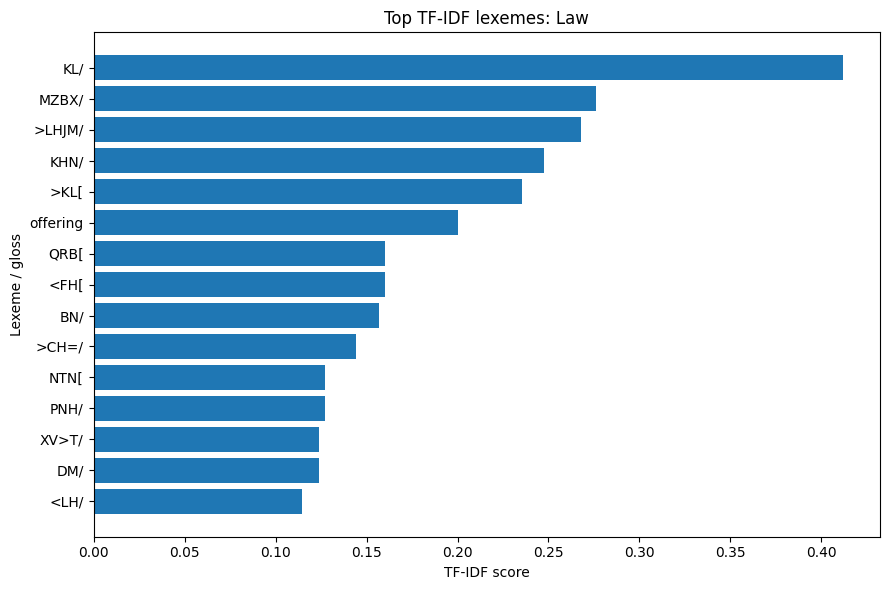

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/top_tfidf_Law_clean.png


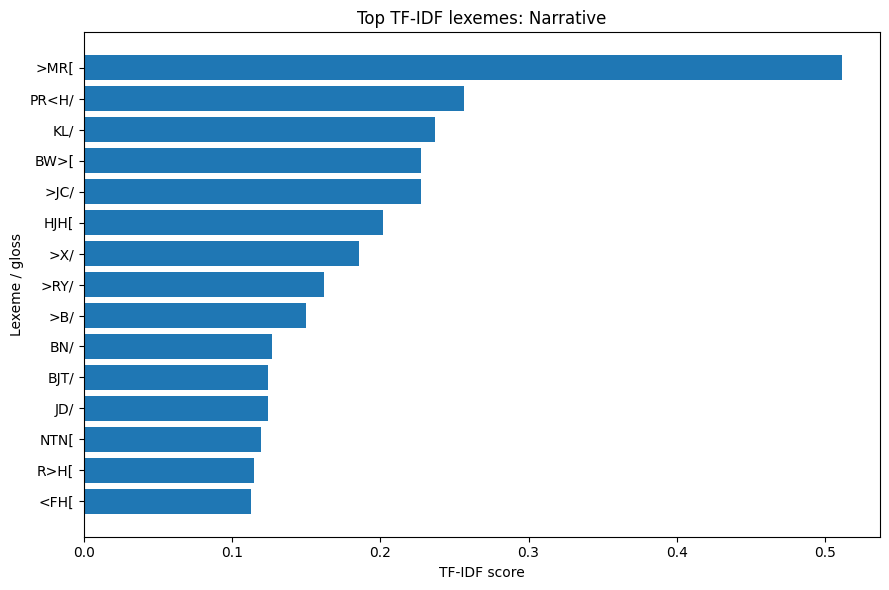

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/top_tfidf_Narrative_clean.png


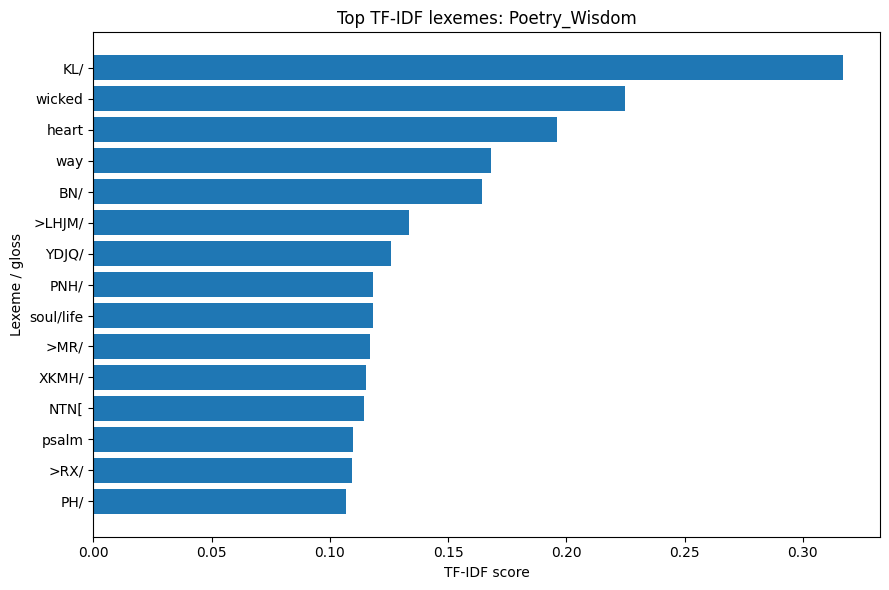

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/top_tfidf_Poetry_Wisdom_clean.png


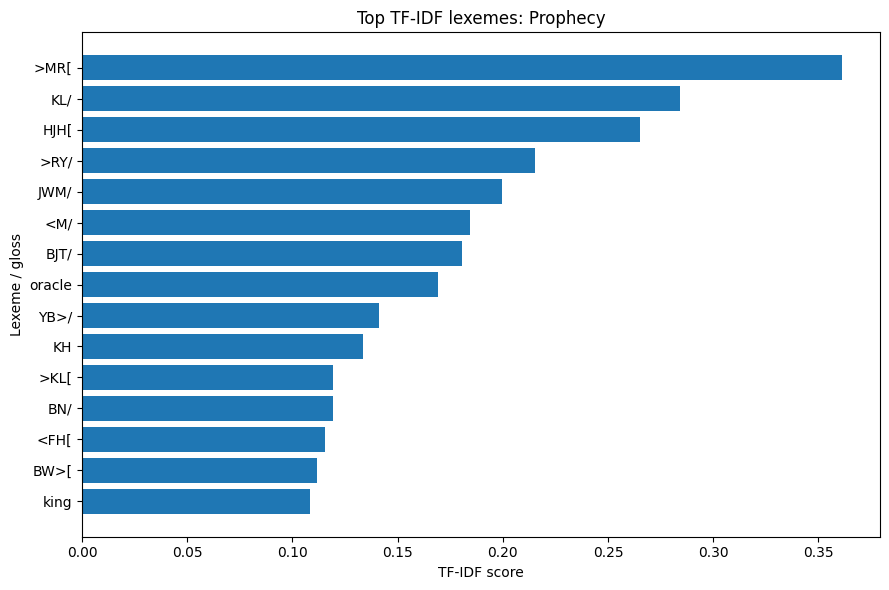

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/top_tfidf_Prophecy_clean.png


In [7]:
for genre, group in top_15_tfidf.groupby("genre"):
    plot_data = group.sort_values("tfidf", ascending=True).tail(15)

    plt.figure(figsize=(9, 6))
    plt.barh(plot_data["display"], plot_data["tfidf"])
    plt.xlabel("TF-IDF score")
    plt.ylabel("Lexeme / gloss")
    plt.title(f"Top TF-IDF lexemes: {genre}")
    plt.tight_layout()

    filename = FIGURES_DIR / f"top_tfidf_{genre}_clean.png"
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", filename)

## 8. Interpretation checkpoint

The results should be interpreted as exploratory. TF-IDF identifies terms that are distinctive within this selected pilot sample, not universally distinctive across all Biblical Hebrew.